# Fotometría sintética y extinción interestelar: el caso de Antares

**Unidad 3 — Sistemas de Magnitudes — Clase 3B (tutorial complementario)**

En la Clase 3B vimos tres bloques de conceptos: **filtros y sistemas fotométricos**,
**sistemas de magnitud (Vega, AB)** y **extinción interestelar / reddening**. Este
notebook los conecta en un solo ejercicio práctico:

1. Construimos un **espectro sintético** de una estrella real (Antares, α Scorpii),
   igual que hicimos con Betelgeuse en la Clase 1, pero ahora lo vamos a "observar"
   a través de **filtros fotométricos** en vez de integrarlo completo.
2. Calculamos **magnitudes sintéticas** en el sistema Vega para los filtros
   Johnson-Cousins *UBVRI*, y sus **colores** intrínsecos.
3. Consultamos la extinción **real** hacia Antares en la herramienta
   [IRSA Dust Extinction Service](https://irsa.ipac.caltech.edu/applications/DUST/)
   (la misma que usamos para VX Sgr) y usamos esos valores para **enrojecer**
   el espectro sintético y ver cómo cambian las magnitudes y los colores observados.

### Objetivos de aprendizaje

- Reforzar la diferencia entre **filtro**, **sistema fotométrico** y **sistema de magnitud**.
- Practicar el paso de "espectro completo" a "magnitud en una banda" (fotometría sintética).
- Aplicar de forma concreta las relaciones $E(B-V) = (B-V)_{obs} - (B-V)_0$ y $A_V = 3.1\,E(B-V)$.
- Ver, con números reales, por qué el mapa de extinción 2D de IRSA da un **límite
  superior** y no el valor exacto para una estrella galáctica cercana.


## 0. Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
import astropy.constants as const
from astropy.modeling.models import BlackBody

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


## 1. El espectro sintético de Antares

Antares (α Scorpii A) es una supergigante roja, muy parecida en espíritu a la
Betelgeuse de la Clase 1: la modelamos como un **cuerpo negro** con la temperatura
efectiva real de la estrella. Los datos de referencia son:

| Parámetro | Valor | Fuente |
|---|---|---|
| Tipo espectral | M1.5 Iab | Wikipedia / literatura general |
| $T_{ef}$ | 3660 ± 120 K | Wikipedia (Antares) |
| Radio | ≈ 680 $R_\odot$ | Literatura (supergigante roja) |
| Distancia | ≈ 170 pc (≈ 550 años luz) | Literatura general |
| Coordenadas J2000 | RA 247.35192°, Dec −26.43200° | IRSA DUST (ver Sección 3) |
| Latitud galáctica | $b \approx +15.06°$ | IRSA DUST (ver Sección 3) |

Como en la Clase 1, generamos $B_\lambda(T)$ con `astropy` y lo convertimos a un
flujo en la Tierra usando el factor de dilución geométrica $(R/d)^2$.


In [2]:
# --- Datos reales de Antares ---
Teff_antares = 3660 * u.K
R_antares = 680 * const.R_sun
d_antares = 170 * u.pc

# --- Espectro de cuerpo negro ---
bb = BlackBody(temperature=Teff_antares)

# grilla de longitud de onda: cubre bien las bandas U (365 nm) a I (806 nm)
wave = np.linspace(200, 1100, 3000) * u.nm

# Radiancia espectral B_lambda -> flujo emitido por la superficie (F = pi * B_lambda)
B_lambda = bb(wave).to(u.erg / (u.s * u.cm**2 * u.AA * u.sr),
                        equivalencies=u.spectral_density(wave))
F_lambda_superficie = (np.pi * u.sr) * B_lambda

# Diluido a la distancia de la Tierra (mismo tipo de factor (R/d)^2 que en Clase 1)
dilucion = (R_antares / d_antares).to(u.dimensionless_unscaled) ** 2
F_lambda_tierra = (F_lambda_superficie * dilucion).to(u.erg / (u.s * u.cm**2 * u.AA))

print(f"Factor de dilución (R/d)^2 = {dilucion:.3e}")
print(f"Flujo máximo en la Tierra: {F_lambda_tierra.max():.3e}")


Factor de dilución (R/d)^2 = 8.133e-15
Flujo máximo en la Tierra: 6.873e-09 erg / (Angstrom s cm2)


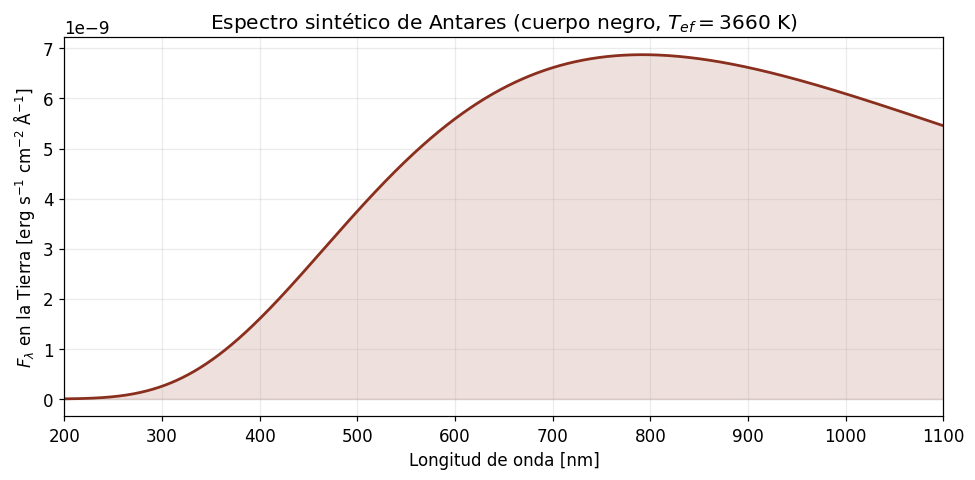

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wave.value, F_lambda_tierra.value, color="#8a2f1e", lw=1.8)
ax.fill_between(wave.value, F_lambda_tierra.value, color="#8a2f1e", alpha=0.15)
ax.set_xlabel("Longitud de onda [nm]")
ax.set_ylabel(r"$F_\lambda$ en la Tierra [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("Espectro sintético de Antares (cuerpo negro, $T_{ef}=3660$ K)")
ax.set_xlim(200, 1100)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 2. Curvas de transmisión de los filtros (Johnson-Cousins *UBVRI*)

Recordemos la distinción de la Clase 3B: un **filtro** es un elemento físico con
una curva de transmisión $T(\lambda)$; el conjunto {U, B, V, R, I} construido de
forma consistente es un **sistema fotométrico** (Johnson-Cousins); y **Vega** es
el **sistema de magnitud** que usamos para convertir flujo en magnitud.

Aquí aproximamos cada filtro como una curva gaussiana centrada en su longitud de
onda efectiva $\lambda_{ef}$, con el ancho (FWHM) típico del sistema Johnson-Cousins
(valores estándar, ver p.ej. Bessell 1998, PASP). También incluimos el **flujo de
punto cero** $F_0$ de cada banda: el flujo que, por definición, correspondería a
magnitud 0 en el sistema Vega.


In [4]:
# Valores estándar Johnson-Cousins (aprox., Bessell 1998, PASP 110, 863)
# lam_ef y fwhm en nm; F0 en erg / s / cm^2 / Angstrom (flujo de punto cero, sistema Vega)
filtros = {
    "U": {"lam_ef": 365.0, "fwhm": 66.0,  "F0": 4.27e-9, "color": "#7b2cbf"},
    "B": {"lam_ef": 445.0, "fwhm": 94.0,  "F0": 6.61e-9, "color": "#2274a5"},
    "V": {"lam_ef": 551.0, "fwhm": 88.0,  "F0": 3.64e-9, "color": "#3aab5f"},
    "R": {"lam_ef": 658.0, "fwhm": 138.0, "F0": 1.74e-9, "color": "#e07a2f"},
    "I": {"lam_ef": 806.0, "fwhm": 149.0, "F0": 8.32e-10,"color": "#c1272d"},
}

def transmision(lam_nm, lam_ef, fwhm):
    '''Curva de transmisión gaussiana normalizada a maximo = 1.'''
    sigma = fwhm / 2.3548
    return np.exp(-0.5 * ((lam_nm - lam_ef) / sigma) ** 2)

for nombre, datos in filtros.items():
    datos["T"] = transmision(wave.value, datos["lam_ef"], datos["fwhm"])

print("Filtros definidos:", list(filtros.keys()))


Filtros definidos: ['U', 'B', 'V', 'R', 'I']


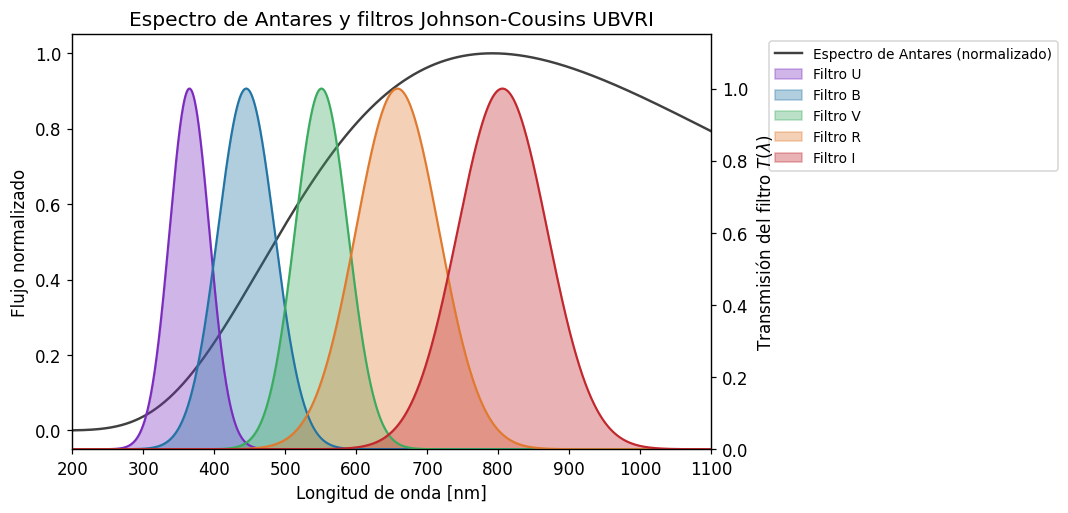

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(wave.value, F_lambda_tierra.value / F_lambda_tierra.value.max(),
         color="0.25", lw=1.6, label="Espectro de Antares (normalizado)")

ax2 = ax1.twinx()
for nombre, datos in filtros.items():
    ax2.plot(wave.value, datos["T"], color=datos["color"], lw=1.4)
    ax2.fill_between(wave.value, datos["T"], color=datos["color"], alpha=0.35,
                      label=f"Filtro {nombre}")

ax1.set_xlabel("Longitud de onda [nm]")
ax1.set_ylabel("Flujo normalizado")
ax2.set_ylabel("Transmisión del filtro $T(\\lambda)$")
ax1.set_xlim(200, 1100)
ax2.set_ylim(0, 1.15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left",
           bbox_to_anchor=(1.08, 1.0), fontsize=9, frameon=True)
ax1.set_title("Espectro de Antares y filtros Johnson-Cousins UBVRI")
plt.tight_layout()
plt.show()


## 3. Fotometría sintética: de espectro a magnitud

El flujo que "ve" un filtro es el promedio de $F_\lambda$ ponderado por su
transmisión:

$$\bar{F}_{filtro} = \frac{\int F_\lambda\, T(\lambda)\, d\lambda}{\int T(\lambda)\, d\lambda}$$

Igual que en la Clase 1 (donde reemplazamos la suma de Riemann por **trapecios**),
calculamos ambas integrales con una regla trapezoidal explícita, y luego pasamos
a magnitud con el punto cero de Vega:

$$m_{filtro} = -2.5\log_{10}\!\left(\frac{\bar{F}_{filtro}}{F_{0,\,filtro}}\right)$$


In [6]:
def integral_trapecios(x, y):
    '''Integración trapezoidal explícita (mismo método que en la Clase 1).'''
    total = 0.0 * (x.unit * y.unit) if hasattr(y, "unit") else 0.0
    n = len(x)
    for i in range(n - 1):
        dx = x[i + 1] - x[i]
        total += 0.5 * (y[i] + y[i + 1]) * dx
    return total


def fotometria_sintetica(wave_nm, F_lambda, filtros):
    '''Devuelve el flujo promedio ponderado por cada filtro (mismas unidades que F_lambda).'''
    resultados = {}
    for nombre, datos in filtros.items():
        T = datos["T"] * u.dimensionless_unscaled
        numerador = integral_trapecios(wave_nm, F_lambda * T)
        denominador = integral_trapecios(wave_nm, T)
        resultados[nombre] = (numerador / denominador).to(F_lambda.unit)
    return resultados


flujos_intrinsecos = fotometria_sintetica(wave, F_lambda_tierra, filtros)
for nombre, F in flujos_intrinsecos.items():
    print(f"F_{nombre} = {F:.3e}")


F_U = 1.035e-09 erg / (Angstrom s cm2)
F_B = 2.563e-09 erg / (Angstrom s cm2)
F_V = 4.731e-09 erg / (Angstrom s cm2)
F_R = 6.148e-09 erg / (Angstrom s cm2)
F_I = 6.769e-09 erg / (Angstrom s cm2)


In [7]:
def flujo_a_magnitud(F, F0):
    razon = (F / (F0 * u.erg / (u.s * u.cm**2 * u.AA))).to(u.dimensionless_unscaled).value
    return -2.5 * np.log10(razon)


mags_intrinsecas = {nombre: flujo_a_magnitud(flujos_intrinsecos[nombre], datos["F0"])
                    for nombre, datos in filtros.items()}

tabla_intrinseca = pd.DataFrame({
    "lambda_ef [nm]": [filtros[n]["lam_ef"] for n in filtros],
    "F_filtro [erg/s/cm2/A]": [f"{flujos_intrinsecos[n].value:.3e}" for n in filtros],
    "m (Vega, sin extinción)": [f"{mags_intrinsecas[n]:.3f}" for n in filtros],
}, index=list(filtros.keys()))
tabla_intrinseca


,lambda_ef [nm],F_filtro [erg/s/cm2/A],"m (Vega, sin extinción)"
U,365.0,1.035e-09,1.539
B,445.0,2.563e-09,1.028
V,551.0,4.731e-09,-0.285
R,658.0,6.148e-09,-1.371
I,806.0,6.769e-09,-2.276


In [8]:
B_V0 = mags_intrinsecas["B"] - mags_intrinsecas["V"]
V_R0 = mags_intrinsecas["V"] - mags_intrinsecas["R"]
V_I0 = mags_intrinsecas["V"] - mags_intrinsecas["I"]

print(f"Color intrínseco (B-V)_0 = {B_V0:.3f}")
print(f"Color intrínseco (V-R)_0 = {V_R0:.3f}")
print(f"Color intrínseco (V-I)_0 = {V_I0:.3f}")
print()
print("Nota: al ser un cuerpo negro puro (sin líneas ni bandas moleculares como las")
print("que realmente tiene una M1.5 Iab), estos valores son una aproximación —")
print("igual que en la Clase 1 con Betelgeuse. Sirven para el ejercicio de método,")
print("no para reproducir exactamente la fotometría publicada de Antares.")


Color intrínseco (B-V)_0 = 1.313
Color intrínseco (V-R)_0 = 1.086
Color intrínseco (V-I)_0 = 1.991

Nota: al ser un cuerpo negro puro (sin líneas ni bandas moleculares como las
que realmente tiene una M1.5 Iab), estos valores son una aproximación —
igual que en la Clase 1 con Betelgeuse. Sirven para el ejercicio de método,
no para reproducir exactamente la fotometría publicada de Antares.


## 4. Extinción real hacia Antares (IRSA Dust Extinction Service)

Ahora hacemos lo mismo que hicimos para VX Sgr: consultamos la extinción de línea
de visión en [irsa.ipac.caltech.edu/applications/DUST](https://irsa.ipac.caltech.edu/applications/DUST/).

**Pasos para reproducirlo tú mismo:**

1. Entra a la página y en el campo *Coordinate/Object* escribe `Antares` (o sus
   coordenadas). Dejamos el tamaño de imagen en 2°.
2. Presiona *Submit* y espera el resultado (puede tardar 1-2 minutos, genera un
   mosaico en el servidor).
3. En la tabla de resultados, anota el **E(B−V) Reddening**, columnas *S&F (2011)*
   y *SFD (1998)*, fila *Mean* (dentro del radio de 5 arcmin).

Estos son los valores reales que obtuvimos consultando la herramienta:


In [9]:
# --- Datos reales obtenidos de irsa.ipac.caltech.edu/applications/DUST/ ---
# Consulta: "Antares", radio de estadística = 5 arcmin (25-09-2026)
antares_dust = {
    "ra_j2000": 247.35192,
    "dec_j2000": -26.43200,
    "l_gal": 351.94710,
    "b_gal": 15.06438,
    "EBV_SF_mean": 0.4751,      # Schlafly & Finkbeiner (2011), recomendado
    "EBV_SF_err": 0.0039,
    "EBV_SFD_mean": 0.5525,     # Schlegel, Finkbeiner & Davis (1998), original
    "EBV_SFD_err": 0.0045,
    "AV_SF": 1.4666,            # A_V = 3.1 * E(B-V)_S&F, reportado por la propia página
    "AV_SFD": 1.7054,
}

print(f"Antares: l = {antares_dust['l_gal']:.2f}°,  b = {antares_dust['b_gal']:.2f}°  (latitud galáctica)")
print()
print(f"E(B-V) S&F (2011)  = {antares_dust['EBV_SF_mean']:.4f} ± {antares_dust['EBV_SF_err']:.4f} mag")
print(f"E(B-V) SFD (1998)  = {antares_dust['EBV_SFD_mean']:.4f} ± {antares_dust['EBV_SFD_err']:.4f} mag")
print(f"A_V (S&F, recomendado) = {antares_dust['AV_SF']:.4f} mag")
print(f"A_V (SFD)              = {antares_dust['AV_SFD']:.4f} mag")


Antares: l = 351.95°,  b = 15.06°  (latitud galáctica)

E(B-V) S&F (2011)  = 0.4751 ± 0.0039 mag
E(B-V) SFD (1998)  = 0.5525 ± 0.0045 mag
A_V (S&F, recomendado) = 1.4666 mag
A_V (SFD)              = 1.7054 mag


### Interpretando el resultado

Comparemos con VX Sgr, visto en la clase anterior:

| Estrella | $b$ (lat. galáctica) | $E(B-V)_{S\&F}$ | $A_V$ |
|---|---|---|---|
| VX Sgr | ≈ −1° (casi en el plano) | ≈ 6.4 mag | ≈ 20 mag |
| Antares | ≈ +15° (bastante fuera del plano) | ≈ 0.48 mag | ≈ 1.47 mag |

El valor de Antares es mucho más razonable que el de VX Sgr — y no es casualidad:
al estar 15° fuera del plano galáctico, la línea de visión atraviesa mucho menos
columna de polvo que la de VX Sgr, que mira casi exactamente a lo largo del disco.

Pero sigue aplicando la **misma advertencia** de la clase anterior: este mapa es
**2D** y da la extinción **total integrada hasta el infinito** en esa dirección.
Antares está a solo ≈170 pc, así que la extinción que efectivamente sufre su luz
es probablemente algo menor que este valor (que también incluye polvo detrás de
la estrella). Para esta actividad, de todas formas, vamos a **usar el valor de
IRSA tal cual** ($E(B-V)=0.475$, $A_V=1.47$ mag) como ejercicio de aplicación del
método — con la salvedad explícita de que, para un análisis real y riguroso, lo
correcto sería consultar un mapa 3D (STILISM o Bayestar) a la distancia real de
la estrella, como vimos en la respuesta anterior.


## 5. "Enrojeciendo" el espectro sintético

Con $E(B-V)$ y $A_V$ reales tenemos **dos puntos de anclaje** de la curva de
extinción $A_\lambda$: por definición,

$$A_V = A_\lambda(\lambda_V) \qquad\text{y}\qquad A_B = A_V + E(B-V)$$

Aproximamos la forma de $A_\lambda$ entre esos dos puntos (y más allá, para
extrapolar a U, R e I) con una ley de potencia simple:

$$A_\lambda = A_V \left(\frac{\lambda_V}{\lambda}\right)^{p}$$

que es una aproximación pedagógica de curvas de extinción reales más completas
como la de Cardelli, Clayton & Mathis (1989) o Fitzpatrick (1999): captura la
idea esencial de que el polvo **extingue más en el azul que en el rojo**, pero
sin toda la complejidad de esas leyes. El exponente $p$ lo calibramos exigiendo
que la ley reproduzca el $E(B-V)$ real medido por IRSA entre B y V.


In [10]:
A_V_real = antares_dust["AV_SF"]
E_BV_real = antares_dust["EBV_SF_mean"]
A_B_real = A_V_real + E_BV_real

lam_V = filtros["V"]["lam_ef"]
lam_B = filtros["B"]["lam_ef"]

p = np.log(A_B_real / A_V_real) / np.log(lam_V / lam_B)
print(f"A_V = {A_V_real:.4f} mag,  A_B = {A_B_real:.4f} mag  ->  exponente calibrado p = {p:.3f}")

def A_lambda(lam_nm, A_V=A_V_real, lam_V=lam_V, p=p):
    return A_V * (lam_V / lam_nm) ** p

A_lam_curva = A_lambda(wave.value)


A_V = 1.4666 mag,  A_B = 1.9417 mag  ->  exponente calibrado p = 1.313


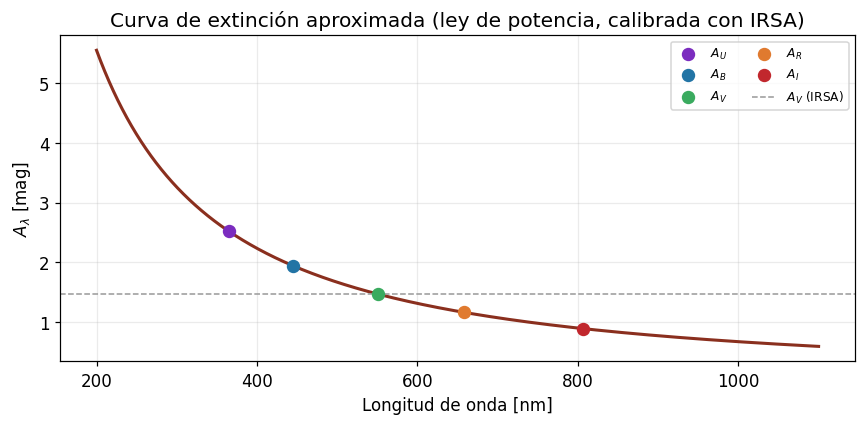

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wave.value, A_lam_curva, color="#8a2f1e", lw=2)
for nombre, datos in filtros.items():
    ax.scatter([datos["lam_ef"]], [A_lambda(datos["lam_ef"])], color=datos["color"],
               s=60, zorder=5, label=f"$A_{{{nombre}}}$")
ax.axhline(A_V_real, color="0.6", ls="--", lw=1, label="$A_V$ (IRSA)")
ax.set_xlabel("Longitud de onda [nm]")
ax.set_ylabel(r"$A_\lambda$ [mag]")
ax.set_title("Curva de extinción aproximada (ley de potencia, calibrada con IRSA)")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


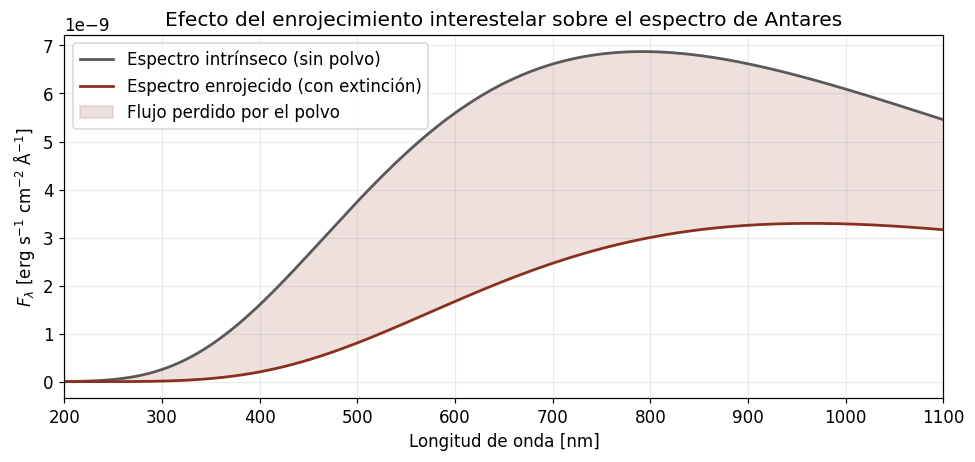

In [12]:
# Atenuación: F_observado(lambda) = F_intrinseco(lambda) * 10^(-0.4 * A_lambda)
atenuacion = 10 ** (-0.4 * A_lam_curva)
F_lambda_enrojecido = F_lambda_tierra * atenuacion

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(wave.value, F_lambda_tierra.value, color="0.35", lw=1.8, label="Espectro intrínseco (sin polvo)")
ax.plot(wave.value, F_lambda_enrojecido.value, color="#8a2f1e", lw=1.8, label="Espectro enrojecido (con extinción)")
ax.fill_between(wave.value, F_lambda_enrojecido.value, F_lambda_tierra.value,
                 color="#8a2f1e", alpha=0.15, label="Flujo perdido por el polvo")
ax.set_xlabel("Longitud de onda [nm]")
ax.set_ylabel(r"$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("Efecto del enrojecimiento interestelar sobre el espectro de Antares")
ax.set_xlim(200, 1100)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Magnitudes y colores observados (con extinción)

Repetimos exactamente la misma fotometría sintética de la Sección 3, pero ahora
sobre el espectro **enrojecido**.


In [13]:
flujos_observados = fotometria_sintetica(wave, F_lambda_enrojecido, filtros)
mags_observadas = {nombre: flujo_a_magnitud(flujos_observados[nombre], datos["F0"])
                   for nombre, datos in filtros.items()}

tabla_comparativa = pd.DataFrame({
    "m intrínseca (m_0)": [f"{mags_intrinsecas[n]:.3f}" for n in filtros],
    "m observada (con extinción)": [f"{mags_observadas[n]:.3f}" for n in filtros],
    "A_filtro = m_obs - m_0": [f"{mags_observadas[n] - mags_intrinsecas[n]:.3f}" for n in filtros],
}, index=list(filtros.keys()))
tabla_comparativa


,m intrínseca (m_0),m observada (con extinción),A_filtro = m_obs - m_0
U,1.539,3.951,2.412
B,1.028,2.898,1.870
V,-0.285,1.166,1.450
R,-1.371,-0.216,1.154
I,-2.276,-1.382,0.894


In [14]:
B_V_obs = mags_observadas["B"] - mags_observadas["V"]

print(f"(B-V)_0   (intrínseco, sin polvo)     = {B_V0:.3f}")
print(f"(B-V)_obs (con extinción, sintético)  = {B_V_obs:.3f}")
print(f"(B-V)_obs - (B-V)_0                   = {B_V_obs - B_V0:.3f}")
print(f"E(B-V) real (IRSA, S&F 2011)          = {E_BV_real:.3f}")
print()
print("Las dos últimas líneas son parecidas pero no idénticas, y eso es esperable:")
print("calibramos A_B - A_V exactamente en las longitudes de onda centrales de B y V,")
print("pero la magnitud sintética de cada filtro es un promedio ponderado sobre todo")
print("su ancho de banda (Sección 3). Como el espectro y la extinción varían dentro")
print("de cada filtro, el color de banda ancha resultante no coincide con el valor")
print("'monocromático' que usamos para calibrar la ley. Esta diferencia entre")
print("extinción monocromática y extinción de banda ancha es un efecto real en")
print("fotometría (relacionado con lo que se llama extinción de 'segundo orden'),")
print("no un error de cálculo. Aun así, ambos números coinciden en orden de")
print("magnitud, lo que confirma que la relación E(B-V) = (B-V)_obs - (B-V)_0")
print("de la Clase 3B funciona como se espera.")


(B-V)_0   (intrínseco, sin polvo)     = 1.313
(B-V)_obs (con extinción, sintético)  = 1.733
(B-V)_obs - (B-V)_0                   = 0.420
E(B-V) real (IRSA, S&F 2011)          = 0.475

Las dos últimas líneas son parecidas pero no idénticas, y eso es esperable:
calibramos A_B - A_V exactamente en las longitudes de onda centrales de B y V,
pero la magnitud sintética de cada filtro es un promedio ponderado sobre todo
su ancho de banda (Sección 3). Como el espectro y la extinción varían dentro
de cada filtro, el color de banda ancha resultante no coincide con el valor
'monocromático' que usamos para calibrar la ley. Esta diferencia entre
extinción monocromática y extinción de banda ancha es un efecto real en
fotometría (relacionado con lo que se llama extinción de 'segundo orden'),
no un error de cálculo. Aun así, ambos números coinciden en orden de
magnitud, lo que confirma que la relación E(B-V) = (B-V)_obs - (B-V)_0
de la Clase 3B funciona como se espera.


## 7. El camino inverso: "desenrojecer" (corrección de extinción)

En la práctica observacional el orden es al revés: uno mide $m_{obs}$, conoce (o
estima) $A_\lambda$ para su línea de visión, y corrige:

$$m_0 = m_{obs} - A_\lambda$$

Verifiquemos que, aplicando esta corrección a nuestras magnitudes "observadas",
recuperamos las magnitudes intrínsecas originales.


In [15]:
mags_corregidas = {nombre: mags_observadas[nombre] - A_lambda(datos["lam_ef"])
                   for nombre, datos in filtros.items()}

tabla_correccion = pd.DataFrame({
    "m observada": [f"{mags_observadas[n]:.3f}" for n in filtros],
    "A_filtro aplicado": [f"{A_lambda(filtros[n]['lam_ef']):.3f}" for n in filtros],
    "m corregida (desenrojecida)": [f"{mags_corregidas[n]:.3f}" for n in filtros],
    "m intrínseca original": [f"{mags_intrinsecas[n]:.3f}" for n in filtros],
}, index=list(filtros.keys()))
tabla_correccion


,m observada,A_filtro aplicado,m corregida (desenrojecida),m intrínseca original
U,3.951,2.519,1.432,1.539
B,2.898,1.942,0.957,1.028
V,1.166,1.467,-0.301,-0.285
R,-0.216,1.162,-1.378,-1.371
I,-1.382,0.890,-2.271,-2.276


## 8. Resumen y actividad sugerida

- Construimos un espectro sintético de Antares (cuerpo negro, $T_{ef}=3660$ K) y
  lo "observamos" a través de filtros UBVRI, obteniendo magnitudes y colores
  **intrínsecos** — el mismo tipo de cálculo que en la Clase 1, pero banda por
  banda en vez de integrado a todo el espectro.
- Consultamos la extinción **real** hacia Antares en IRSA DUST: $E(B-V)\approx 0.48$
  mag, $A_V\approx 1.47$ mag — mucho menor que la de VX Sgr, porque Antares está
  lejos del plano galáctico, pero **todavía un límite superior**, no el valor
  exacto a la distancia de la estrella.
- Usamos esos dos números reales para calibrar una ley de extinción simple,
  enrojecer el espectro completo, y verificar numéricamente que
  $E(B-V) = (B-V)_{obs} - (B-V)_0$ y $A_V = 3.1\,E(B-V)$ son consistentes de
  principio a fin.

**Para la práctica de laboratorio**, cada estudiante puede repetir este notebook
cambiando:

1. La estrella (`Teff_antares`, `R_antares`, `d_antares`) — prueben con otra
   estrella real de tipo espectral distinto (por ejemplo, una B o una G).
2. Los datos de extinción: consulten su propia estrella en
   [irsa.ipac.caltech.edu/applications/DUST](https://irsa.ipac.caltech.edu/applications/DUST/)
   y reemplacen el diccionario `antares_dust` de la Sección 4.
3. Comparen el $(B-V)_0$ sintético con el valor típico tabulado para el tipo
   espectral de su estrella — ¿qué tan bien lo reproduce el modelo de cuerpo negro?

### Fuentes

- Antares: coordenadas, $T_{ef}$, tipo espectral y distancia — [Wikipedia: Antares](https://en.wikipedia.org/wiki/Antares).
- Extinción: [IRSA Galactic Dust Reddening & Extinction Service](https://irsa.ipac.caltech.edu/applications/DUST/), consulta a "Antares", radio 5 arcmin.
- Schlegel, Finkbeiner & Davis (1998), *ApJ* 500, 525 (mapa SFD).
- Schlafly & Finkbeiner (2011), *ApJ* 737, 103 (recalibración S&F).
- Valores estándar de filtros Johnson-Cousins: Bessell (1998), *PASP* 110, 863.
